In [1]:
%pip install -U langgraph langchain langchain-core langchain-google-genai python-dotenv
import os
from typing import TypedDict

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise ValueError("GEMINI_API_KEY not found in .env file")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key=api_key
)

print("Gemini initialized successfully!")

Note: you may need to restart the kernel to use updated packages.
Gemini initialized successfully!


![mermaid-diagram (2).png](<attachment:mermaid-diagram (2).png>)
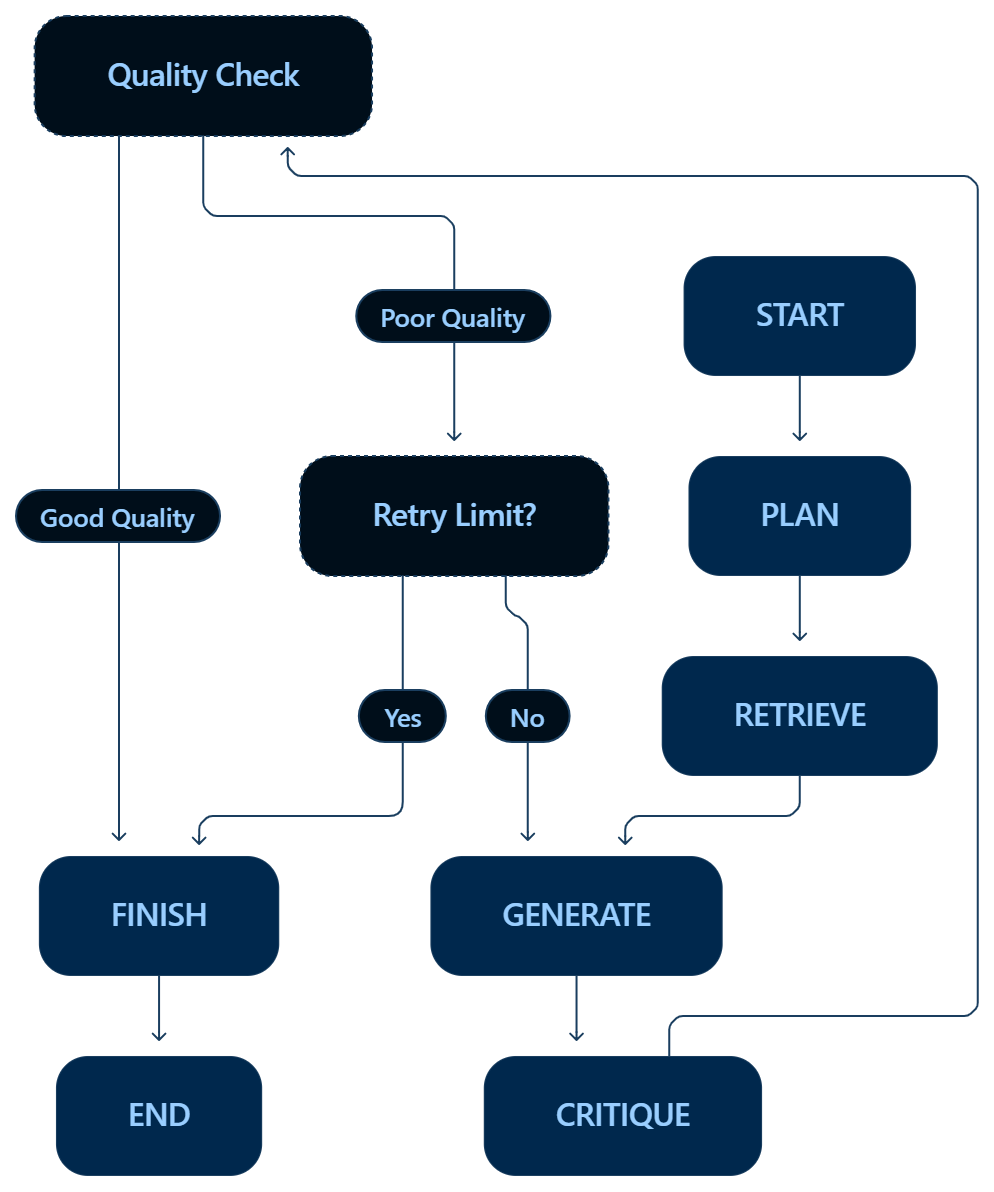

In [2]:
# State Design 
class ResearchState(TypedDict):
    question: str
    draft: str
    critique: str
    quality_score: int
    retry_count: int
    max_retries: int
    final_answer: str

print("ResearchState created successfully!")

for field in ResearchState.__annotations__:
    print("-", field)

ResearchState created successfully!
- question
- draft
- critique
- quality_score
- retry_count
- max_retries
- final_answer


In [3]:
def get_text(response):
    if isinstance(response.content, str):
        return response.content

    if isinstance(response.content, list):
        return "\n".join(
            item["text"]
            for item in response.content
            if isinstance(item, dict) and item.get("type") == "text"
        )

    return str(response.content)

In [5]:
def generate_node(state):
    print(f"\n[Generate] Attempt {state['retry_count'] + 1}")

    response = llm.invoke(
        f"""Answer the following question clearly and accurately.

Question:
{state["question"]}

If a previous critique exists, improve the answer according to it.

Previous critique:
{state["critique"]}

Write a complete answer."""
    )

    return {
        "draft": get_text(response),
        "retry_count": state["retry_count"] + 1
    }


In [7]:
def critique_node(state):
    print("[Critique] Evaluating generated answer...")

    response = llm.invoke(
        f"""Critically evaluate the following answer.

Question:
{state["question"]}

Answer:
{state["draft"]}

Give a quality score from 0 to 100.

Then briefly explain what is good and what should be improved.

Use this format:

Score: <number>
Feedback: <brief feedback>"""
    )

    critique = get_text(response)

    score = 0

    for line in critique.splitlines():
        if line.lower().startswith("score:"):
            try:
                score = int(
                    line.split(":", 1)[1].strip().split()[0]
                )
            except:
                score = 0

    return {
        "critique": critique,
        "quality_score": score
    }


In [8]:
def quality_router(state):
    score = state["quality_score"]
    retries = state["retry_count"]
    max_retries = state["max_retries"]

    print(
        f"[Router] Quality Score: {score} | "
        f"Retries: {retries}/{max_retries}"
    )

    if score >= 70:
        print("[Router] Quality acceptable → END")
        return "finish"

    if retries < max_retries:
        print("[Router] Quality low → GENERATE again")
        return "retry"

    print("[Router] Maximum retries reached → END")
    return "finish"

In [10]:
def finish_node(state):
    return {
        "final_answer": state["draft"]
    }


In [12]:
graph_builder = StateGraph(ResearchState)

graph_builder.add_node("generate", generate_node)
graph_builder.add_node("critique", critique_node)
graph_builder.add_node("finish", finish_node)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", "critique")

graph_builder.add_conditional_edges(
    "critique",
    quality_router,
    {
        "retry": "generate",
        "finish": "finish"
    }
)

graph_builder.add_edge("finish", END)

graph = graph_builder.compile()


In [13]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate(generate)
	critique(critique)
	finish(finish)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate;
	critique -.-> finish;
	critique -. &nbsp;retry&nbsp; .-> generate;
	generate --> critique;
	finish --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [14]:
question = "What are the benefits of artificial intelligence?"

initial_state = {
    "question": question,
    "draft": "",
    "critique": "",
    "quality_score": 0,
    "retry_count": 0,
    "max_retries": 3,
    "final_answer": ""
}

result = graph.invoke(initial_state)


[Generate] Attempt 1


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[Critique] Evaluating generated answer...


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[Router] Quality Score: 95 | Retries: 1/3
[Router] Quality acceptable → END


In [ ]:
print("FINAL ANSWER")
print(result["final_answer"])

print("\n" + "=" * 60)
print("FINAL QUALITY SCORE")
print("=" * 60)
print(result["quality_score"])

print("\n" + "=" * 60)
print("TOTAL ATTEMPTS")
print("=" * 60)
print(result["retry_count"])

print("\n" + "=" * 60)
print("CRITIQUE")
print("=" * 60)
print(result["critique"])

FINAL ANSWER
Artificial intelligence (AI) offers a wide range of benefits across various industries, significantly transforming how we live and work. Here are the key benefits of AI:

1. **Automation of Repetitive Tasks:** AI and robotic process automation can handle routine, mundane, and time-consuming tasks (such as data entry, invoice processing, and basic customer service inquiries). This frees up human workers to focus on more complex, creative, and strategic responsibilities.

2. **Data-Driven Decision Making:** AI algorithms can process and analyze massive amounts of structured and unstructured data at unprecedented speeds. By identifying patterns, trends, and correlations that humans might miss, AI helps businesses and leaders make faster, more accurate, and objective decisions.

3. **Enhanced Efficiency and Productivity:** Because AI systems can operate 24/7 without fatigue, downtime, or breaks, they drastically increase the speed and output of operations in manufacturing, log

## Task 3 Explanation

Conditional edges were added to evaluate the quality of the generated answer. If the quality score is below the required threshold and retries are available, the workflow loops back from the Critique node to the Generate node for self-correction. A maximum retry counter prevents the graph from running indefinitely. This type of controlled loop is difficult to manage with a simple AgentExecutor loop, while LangGraph provides explicit nodes, conditional edges, state, and cycle control.


In [17]:
question = "How can blockchain technology improve supply chain management?"

In [18]:
initial_state = {
    "question": question,
    "draft": "",
    "critique": "",
    "quality_score": 0,
    "retry_count": 0,
    "max_retries": 3,
    "final_answer": ""
}

result = graph.invoke(initial_state)


[Generate] Attempt 1


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[Critique] Evaluating generated answer...


c:\Users\samir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[Router] Quality Score: 95 | Retries: 1/3
[Router] Quality acceptable → END


In [20]:

print("FINAL ANSWER\n ")
print(result["final_answer"])

print("\n" + "=" * 60)
print("FINAL QUALITY SCORE")
print("=" * 60)
print(result["quality_score"])

print("\n" + "=" * 60)
print("TOTAL ATTEMPTS")
print("=" * 60)
print(result["retry_count"])

print("\n" + "=" * 60)
print("CRITIQUE")
print("=" * 60)
print(result["critique"])

FINAL ANSWER
 
Blockchain technology can significantly improve supply chain management by addressing longstanding issues related to transparency, traceability, security, and efficiency. 

Here are the primary ways blockchain enhances supply chains:

### 1. Enhanced Traceability and Provenance
* **End-to-End Tracking:** Blockchain creates an immutable, timestamped digital record of every transaction and movement of a product from its origin (raw materials) to the final consumer. 
* **Quick Root-Cause Analysis:** If a product is recalled (e.g., contaminated food or a faulty electronic component), blockchain allows companies to pinpoint the exact batch, location, and time of the issue in seconds rather than weeks, minimizing waste and health risks.

### 2. Increased Transparency and Trust
* **Single Source of Truth:** Traditional supply chains involve fragmented data silos where suppliers, manufacturers, logistics providers, and retailers maintain separate ledgers. Blockchain provides a s